# Task 8: Random Forest - Car Acceptability

Machine Learning Fundamentals

## Goal
Train a random forest classifier, evaluate held-out predictions, and inspect feature importance.

## Setup
Run all cells from top to bottom with Python 3. Required packages: numpy, pandas, matplotlib, scipy, scikit-learn, and IPython.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (7, 4), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 8)
pd.set_option("display.width", 88)
SEED = 42
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.0


## Data
Use the provided car_acceptability.csv. The local coursework copy contains 1,727 records; it is used as supplied without filling in extra rows. All six inputs are treated as categorical, including door/person counts. Keep the data folder beside this notebook for offline execution; otherwise the GitHub copy is loaded.

### Check the input data

In [2]:
from pathlib import Path
import hashlib

local_paths = [Path("data/car_acceptability.csv"),
               Path("car_acceptability.csv")]
data_path = next((p for p in local_paths if p.exists()), None)
source = data_path or (
    "https://raw.githubusercontent.com/programmingxpert/"
    "Machine-Learning-Fundamentals/main/"
    "Jupyter%20Notebook%20files/data/car_acceptability.csv"
)
cars = pd.read_csv(source, dtype=str)
print("Rows and columns:", cars.shape)
print("Missing values:", int(cars.isna().sum().sum()))
print("Duplicate rows:", int(cars.duplicated().sum()))
assert not cars.isna().any().any()
assert not cars.duplicated().any()
display(cars.head())
print("Class counts:")
print(cars["evaluation"].value_counts().to_string())

Rows and columns: (1727, 7)
Missing values: 0
Duplicate rows: 0


,buying price,maintenance cost,number of doors,number of persons,lug_boot,safety,evaluation
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


Class counts:
evaluation
unacc    1209
acc       384
good       69
vgood      65


## Method
Use an 80/20 stratified split to retain class proportions. Fit one-hot encoding only on the training partition through a pipeline. This avoids imposing arbitrary numerical distances between categories. The seed makes the split reproducible. Accuracy is supplemented by macro F1 and balanced accuracy because the classes are imbalanced.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    ConfusionMatrixDisplay, f1_score
)

features = cars.drop(columns="evaluation")
target = cars["evaluation"]
train_x, test_x, train_y, test_y = train_test_split(
    features, target, test_size=0.2, stratify=target, random_state=SEED
)
class_order = ["unacc", "acc", "good", "vgood"]
print(f"Training rows: {len(train_x)}; test rows: {len(test_x)}")
print("Majority-class test baseline:",
      round((test_y == train_y.mode()[0]).mean(), 4))

Training rows: 1381; test rows: 346
Majority-class test baseline: 0.6994


### Train the forest
Each tree is fitted to a bootstrap sample; voting combines their predictions.

In [4]:
from sklearn.ensemble import RandomForestClassifier

forest = make_pipeline(
    OneHotEncoder(handle_unknown="ignore"),
    RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
)
forest.fit(train_x, train_y)
predictions = forest.predict(test_x)
print("Trees trained:", forest[-1].n_estimators)

Trees trained: 200


## Results
### Held-out classification performance

In [5]:
accuracy = accuracy_score(test_y, predictions)
macro_f1 = f1_score(test_y, predictions, average="macro")
print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(test_y, predictions):.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(classification_report(test_y, predictions, labels=class_order,
                            zero_division=0))

Accuracy: 0.9798
Balanced accuracy: 0.9365
Macro F1: 0.9576
              precision    recall  f1-score   support

       unacc       0.99      0.99      0.99       242
         acc       0.94      0.97      0.96        77
        good       1.00      0.86      0.92        14
       vgood       1.00      0.92      0.96        13

    accuracy                           0.98       346
   macro avg       0.98      0.94      0.96       346
weighted avg       0.98      0.98      0.98       346



### Confusion matrix
Rows show actual classes and columns show predictions.

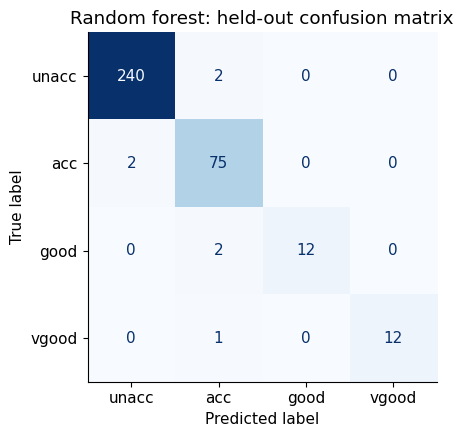

In [6]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ConfusionMatrixDisplay.from_predictions(
    test_y, predictions, labels=class_order, cmap="Blues",
    colorbar=False, ax=ax
)
ax.set_title("Random forest: held-out confusion matrix")
plt.tight_layout()
plt.show()

### Feature importance
Sum the impurity-based importances of one-hot columns back to each original input. These scores describe model splitting behavior, not causal effects.

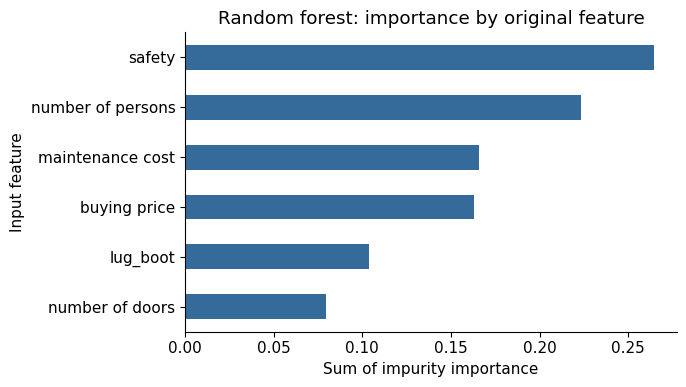

safety               0.2644
number of persons    0.2233
maintenance cost     0.1657
buying price         0.1631
lug_boot             0.1037
number of doors      0.0797


In [7]:
encoder, fitted_forest = forest.steps[0][1], forest.steps[1][1]
importance_rows = []
offset = 0
for feature, categories in zip(features.columns, encoder.categories_):
    width = len(categories)
    score = fitted_forest.feature_importances_[offset:offset + width].sum()
    importance_rows.append((feature, score))
    offset += width
importance = pd.Series(dict(importance_rows)).sort_values()
assert np.isclose(importance.sum(), 1)
fig, ax = plt.subplots()
importance.plot.barh(ax=ax, color="#356b9a")
ax.set(xlabel="Sum of impurity importance", ylabel="Input feature",
       title="Random forest: importance by original feature")
plt.tight_layout()
plt.show()
print(importance.sort_values(ascending=False).round(4).to_string())

## Takeaways

In [8]:
display(Markdown(
    f"The forest correctly classified **{accuracy:.1%}** of the "
    f"{len(test_y)} test records (macro F1 **{macro_f1:.3f}**). "
    f"The largest impurity importance belongs to **{importance.idxmax()}**. "
    "This is one reproducible holdout experiment; results may change with "
    "another split, and feature importance does not establish causality."
))

The forest correctly classified **98.0%** of the 346 test records (macro F1 **0.958**). The largest impurity importance belongs to **safety**. This is one reproducible holdout experiment; results may change with another split, and feature importance does not establish causality.

## Reference and reproducibility
Task scope reference: [Aishani's Task 8 notebook](https://github.com/aishani-dutta1397/Machine-Learning-Fundamentals-Work/blob/main/T8_Random_Forest.ipynb). The reference was consulted for the exercise scope; the code, explanations, validation, and presentation here were independently written. Outputs are generated by the cells above. Cluster numbers, where used, are arbitrary identifiers.